# LangGraph Workflow Patterns

Six standalone patterns are organized below as state/schema, node logic, graph construction, and workflow-specific test steps. Each workflow is followed immediately by its own runner definition and invocation cell.


## Architecture Overview

This notebook demonstrates **six independent LangGraph workflow architectures**. They are not connected into one large graph. Each pattern defines its own state, node functions, edges, compiled graph, and demo runner, while all patterns reuse the same `ChatOpenAI` model.

```text
.env file
    │
    ▼
load_dotenv()
    │
    ▼
Shared ChatOpenAI model: gpt-4.1-mini
    │
    ├── 1. Sequential Workflow
    ├── 2. Parallelization (Fan-Out / Fan-In)
    ├── 3. Conditional Routing
    ├── 4. Orchestrator–Worker with Send()
    ├── 5. Evaluator–Optimizer Loop
    └── 6. Tool-Calling Agent Loop
             │
             ▼
       Workflow-specific test cells
       placed after each graph
```


## Core Components Used Throughout the Notebook

| Component | Purpose in this notebook |
|---|---|
| `TypedDict` | Defines the state fields that move between graph nodes. |
| Pydantic `BaseModel` | Defines reliable structured outputs for routing, report planning, and evaluation. |
| `StateGraph` | Creates a stateful workflow from nodes and edges. |
| `START` and `END` | Mark the entry and exit points of a graph. |
| Node function | Reads the current state and returns a partial state update. |
| `add_edge()` | Creates a fixed transition between nodes. |
| `add_conditional_edges()` | Selects the next node dynamically from the current state. |
| `Send` | Creates a dynamic worker execution with custom input. |
| `Annotated[..., operator.add]` | Combines results returned by multiple parallel workers. |
| `MessagesState` | Stores conversation messages for the tool-calling agent. |
| `ToolNode` | Executes tool calls requested by the model. |
| `compile()` | Converts a graph definition into an executable graph. |
| `invoke()` | Runs a compiled graph with an initial input state. |


## Pattern Comparison and Terminology

| Pattern | Control flow | Approximate model calls per test | Best use |
|---|---|---:|---|
| Sequential Workflow | Fixed sequence | 3 | Refining an output through ordered stages |
| Parallelization | Parallel fan-out and fan-in | 3 | Running independent tasks at the same time |
| Routing | One dynamically selected branch | 2 | Sending a request to the correct specialist |
| Orchestrator–Worker | Dynamic fan-out with `Send` | `1 + N` workers | Breaking a large task into planned sections |
| Evaluator–Optimizer | Feedback loop with a three-attempt limit | 2–6 | Improving quality through review and revision |
| Agent Loop | Model-controlled tool loop | Variable | Solving a task that may require tools |

### Workflow versus agent

A **workflow** follows a graph structure designed by the developer. The model may generate content or choose a route, but the graph controls the available steps. An **agent** has more runtime freedom to decide whether a tool is needed and which action should happen next.

In this notebook, the first five examples are workflow patterns. The sixth example is agent-like because the model decides whether to call `multiply` or `add`. The orchestrator–worker example uses dynamic parallel model tasks; its workers are not separate autonomous agents.

> Model-call counts are approximate for looping and dynamic patterns. The number of orchestrator workers depends on the generated plan, and the number of agent calls depends on the tool decisions.


## Workflow Architectures: Patterns 1–3

### 1. Sequential Workflow

Each node improves the output produced by the previous node. `ChainState` carries `topic`, `draft`, `improved`, and `final` through the sequence.

```text
START → generate → improve → polish → END
          │           │          │
        draft      improved     final
```

### 2. Parallelization (Fan-Out / Fan-In)

Three independent nodes process the same topic. LangGraph waits for all three branches before `aggregate` creates the final output.

```text
                    ┌→ create_summary ────┐
START ──────────────┼→ extract_keywords ──┼→ aggregate → END
                    └→ create_questions ──┘
```

### 3. Conditional Routing

The structured router classifies a query. `route_query` then sends execution to exactly one specialist node.

```text
                         ┌→ technical_support → END
START → router ──────────┼→ billing_support ───→ END
                         └→ general_support ───→ END
```


## Workflow Architectures: Patterns 4–6

### 4. Orchestrator–Worker with `Send`

The orchestrator first asks the model for a structured report plan. `assign_workers` creates one dynamic worker for every planned section. Each worker receives its own `WorkerState`, and `operator.add` merges the completed sections before synthesis.

```text
START → orchestrator → structured section plan
                           │
                           ▼ Send(section)
                 ┌─────────┼─────────┐
                 ▼         ▼         ▼
              worker 1  worker 2  worker N
                 └─────────┼─────────┘
                           ▼ reducer: operator.add
                       synthesizer → END
```

### 5. Evaluator–Optimizer

The generator creates an answer and the evaluator returns a structured status and feedback. Rejected answers loop back for improvement; accepted answers finish. A three-attempt limit prevents an endless loop.

```text
START → generator → evaluator ──accepted──────────→ END
            ▲           │
            └───────────┴──needs_improvement + feedback
```

### 6. Agent Loop with Tools

The model decides whether a calculation tool is required. `ToolNode` executes `multiply` or `add`, appends the tool result to `MessagesState`, and returns control to the model.

```text
START → agent ──no tool call──────────────────────→ END
          │  ▲
          │  └──────── tool result in MessagesState
          ▼
       ToolNode
     (multiply/add)
```


## Code Map and Recommended Execution Order

| Pattern | State/schema | Main nodes | Builder | Test runner |
|---|---|---|---|---|
| Sequential Workflow | `ChainState` | `generate`, `improve`, `polish` | `build_sequential_workflow_graph` | `run_sequential_workflow` |
| Parallelization | `ParallelState` | `create_summary`, `extract_keywords`, `create_questions`, `aggregate` | `build_parallel_graph` | `run_parallelization` |
| Routing | `RouteDecision`, `RouterState` | `router` and three support nodes | `build_routing_graph` | `run_routing` |
| Orchestrator–Worker | `Section`, `Sections`, `OrchestratorState`, `WorkerState` | `orchestrator`, `assign_workers`, `worker`, `synthesizer` | `build_orchestrator_worker_graph` | `run_orchestrator_worker` |
| Evaluator–Optimizer | `Evaluation`, `EvalState` | `generator`, `evaluator`, `evaluation_route` | `build_evaluator_optimizer_graph` | `run_evaluator_optimizer` |
| Agent Loop | `MessagesState` | `agent_node`, `should_continue`, `ToolNode` | `build_agent_graph` | `run_agent_loop` |

Recommended order:

1. Run the environment setup cell.
2. Run the imports and shared-model cells.
3. Run the state, node, and graph-builder cells for the pattern you want to study.
4. Review the test runner placed directly after that graph.
5. Run the following invocation cell, for example `run_orchestrator_worker()`.
6. Continue to the next workflow only when you are ready to make its model calls.


## Environment setup

Load `OPENAI_API_KEY` from the project `.env` file when present. An existing process-level environment variable continues to work as well.


In [1]:
from dotenv import load_dotenv

load_dotenv()

True

## Shared imports and model

This original setup cell imports the required LangGraph, LangChain, and Pydantic components, then creates the shared chat model used by every workflow.


In [2]:
# ============================================================
# LANGGRAPH WORKFLOW PATTERNS
# Complete examples in one file
#
# Patterns covered:
# 1. Sequential Workflow
# 2. Parallelization (Fan-Out / Fan-In)
# 3. Routing
# 4. Orchestrator-Worker with Send()
# 5. Evaluator-Optimizer
# 6. Agent Loop with Tools
#
# Install:
# pip install -U langgraph langchain-openai pydantic
#
# Before running:
# Set OPENAI_API_KEY in your environment.
# ============================================================

from typing import TypedDict, Literal, Annotated
import operator

from pydantic import BaseModel

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.types import Send
from langgraph.prebuilt import ToolNode

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool

In [3]:
# ============================================================
# MODEL
# ============================================================

model = ChatOpenAI(
    model="gpt-4.1-mini",
    temperature=0,
)



### Graph-visualization helper

`show_graph` prints the graph definition in Mermaid format. It does not call the language model, so it is safe to run before the workflow test.


In [4]:
def show_graph(compiled_graph):
    """Print a generated Mermaid graph without making model calls."""

    print(compiled_graph.get_graph().draw_mermaid())


## 1. Sequential Workflow — state

### What this workflow does

A sequential workflow completes one task through a fixed series of steps. The output of one step becomes the input of the next step. Every step runs in the same order.

### How it works

1. `generate` creates the first draft from the topic.
2. `improve` reads that draft and makes it easier for a beginner to understand.
3. `polish` reads the improved version and produces a concise final answer.
4. `ChainState` carries `topic`, `draft`, `improved`, and `final` between the nodes.

```text
Topic → Generate Draft → Improve Draft → Polish Answer → Final Output
```

### Simple real-world example

Imagine preparing a professional email. First, you write a rough email. Next, a colleague improves its clarity. Finally, an editor checks the tone and grammar. This notebook follows the same process for an explanation about Retrieval-Augmented Generation.


In [87]:
# ============================================================
# 1. SEQUENTIAL WORKFLOW
# ============================================================

class ChainState(TypedDict):
    topic: str
    draft: str
    improved: str
    final: str


### 1.1 Sequential workflow nodes

Each node reads the previous state value and returns only the field it updates.


In [88]:
def generate(state: ChainState):
    response = model.invoke(
        f"Write a short explanation about {state['topic']}."
    )

    return {
        "draft": response.content
    }

In [89]:
def improve(state: ChainState):
    response = model.invoke(
        f"""
Improve this explanation and make it beginner friendly:

{state['draft']}
"""
    )

    return {
        "improved": response.content
    }

In [90]:
def polish(state: ChainState):
    response = model.invoke(
        f"""
Polish the following explanation.

Make it concise and clear:

{state['improved']}
"""
    )

    return {
        "final": response.content
    }

### 1.2 Build the sequential workflow graph

The nodes are connected sequentially from `START` to `END`.


In [91]:
def build_sequential_workflow_graph():
    builder = StateGraph(ChainState)

    builder.add_node("generate", generate)
    builder.add_node("improve", improve)
    builder.add_node("polish", polish)

    builder.add_edge(START, "generate")
    builder.add_edge("generate", "improve")
    builder.add_edge("improve", "polish")
    builder.add_edge("polish", END)

    return builder.compile()

### 1.3 Generated graph structure

This diagram is generated from the compiled graph, so it stays aligned with the actual nodes and edges. Running it does not make a model call.


In [92]:
sequential_graph = build_sequential_workflow_graph()

In [93]:
show_graph(sequential_graph)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	generate(generate)
	improve(improve)
	polish(polish)
	__end__([<p>__end__</p>]):::last
	__start__ --> generate;
	generate --> improve;
	improve --> polish;
	polish --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



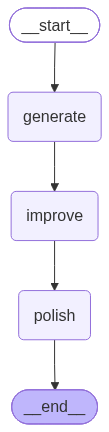

In [94]:
from IPython.display import Image, display

display(
    Image(
        sequential_graph.get_graph().draw_mermaid_png()
    )
)

### 1.4 Test the Sequential Workflow

**Model-call note:** This test makes **3 model calls**.

#### Expected behavior

1. A first draft is generated for Retrieval-Augmented Generation.
2. The draft is rewritten for a beginner and then polished.
3. The final polished explanation is printed.
4. The complete graph state is saved in `sequential_result`.

Run the runner-definition cell first and then run the invocation cell below it.


In [95]:
def run_sequential_workflow():
    print("\n" + "=" * 70)
    print("1. SEQUENTIAL WORKFLOW")
    print("=" * 70)

    graph = build_sequential_workflow_graph()

    result = graph.invoke(
        {
            "topic": "Retrieval-Augmented Generation"
        }
    )

    print(
        result["final"]
    )

    return result


In [96]:
sequential_result = run_sequential_workflow()



1. SEQUENTIAL WORKFLOW
Certainly! Here's a polished, concise version of your explanation:

---

**Retrieval-Augmented Generation (RAG)** is a technique that improves language models by letting them first search external sources—like databases or documents—for relevant information. The model then uses this retrieved data to generate more accurate, detailed, and current answers, especially for questions requiring specific or recent facts.

---

Let me know if you'd like it simplified further or illustrated with examples!


#### Common mistakes

- Running the test before defining all three nodes.
- Expecting the nodes to run in parallel even though the edges define a fixed order.
- Forgetting the required `topic` input.

#### Student exercise

Add a `fact_check` node between `improve` and `polish`, then store its output in a new state field.


## 2. Parallelization — state

### What this workflow does

A parallel workflow runs independent tasks at the same time and combines their results at the end. This can reduce the total waiting time when the tasks do not depend on one another.

### How it works

1. The same topic is sent to three nodes.
2. `create_summary` writes a short summary.
3. `extract_keywords` finds five important keywords.
4. `create_questions` prepares three interview questions.
5. `aggregate` waits for all branches and combines their results into `final_output`.

```text
             ┌→ Summary ─────┐
Topic ───────┼→ Keywords ────┼→ Combine Results → Final Output
             └→ Questions ────┘
```

### Simple real-world example

Imagine preparing for a job interview. One student writes a topic summary, another collects important keywords, and a third prepares interview questions. They work independently, and their work is combined into one study sheet. The notebook performs these three tasks for the topic `LangGraph`.


In [97]:
# ============================================================
# 2. PARALLELIZATION - FAN OUT / FAN IN
# ============================================================

class ParallelState(TypedDict):
    topic: str
    summary: str
    keywords: str
    questions: str
    final_output: str



### 2.1 Parallel worker nodes and aggregator

The summary, keywords, and questions branches can run concurrently; `aggregate` combines them.


In [98]:
def create_summary(state: ParallelState):
    response = model.invoke(
        f"Summarize {state['topic']}."
    )

    return {
        "summary": response.content
    }

In [99]:
def extract_keywords(state: ParallelState):
    response = model.invoke(
        f"Give 5 important keywords related to {state['topic']}."
    )

    return {
        "keywords": response.content
    }

In [100]:
def create_questions(state: ParallelState):
    response = model.invoke(
        f"Create 3 interview questions about {state['topic']}."
    )

    return {
        "questions": response.content
    }

In [101]:
def aggregate(state: ParallelState):
    final = f"""
SUMMARY
-------
{state['summary']}

KEYWORDS
--------
{state['keywords']}

QUESTIONS
---------
{state['questions']}
"""

    return {
        "final_output": final
    }

### 2.2 Build the fan-out/fan-in graph

`START` fans out to three nodes, which fan in to the single aggregation node.


In [102]:
def build_parallel_graph():
    builder = StateGraph(ParallelState)

    builder.add_node("summary", create_summary)
    builder.add_node("keywords", extract_keywords)
    builder.add_node("questions", create_questions)
    builder.add_node("aggregate", aggregate)

    # FAN OUT
    builder.add_edge(START, "summary")
    builder.add_edge(START, "keywords")
    builder.add_edge(START, "questions")

    # FAN IN
    builder.add_edge("summary", "aggregate")
    builder.add_edge("keywords", "aggregate")
    builder.add_edge("questions", "aggregate")

    builder.add_edge("aggregate", END)

    return builder.compile()


### 2.3 Generated graph structure

This diagram is generated from the compiled graph, so it stays aligned with the actual nodes and edges. Running it does not make a model call.


In [103]:
parallel_graph = build_parallel_graph()
show_graph(parallel_graph)


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	summary(summary)
	keywords(keywords)
	questions(questions)
	aggregate(aggregate)
	__end__([<p>__end__</p>]):::last
	__start__ --> keywords;
	__start__ --> questions;
	__start__ --> summary;
	keywords --> aggregate;
	questions --> aggregate;
	summary --> aggregate;
	aggregate --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



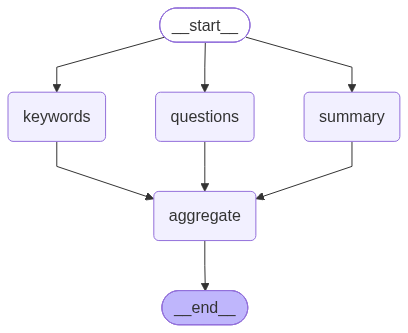

In [104]:
from IPython.display import Image, display

display(
    Image(
        parallel_graph.get_graph().draw_mermaid_png()
    )
)

### 2.4 Test the Parallelization Workflow

**Model-call note:** This test makes **3 independent model calls**, which LangGraph can schedule in parallel.

#### Expected behavior

1. The summary, keyword, and question nodes receive the same topic.
2. All three branches finish before `aggregate` runs.
3. The combined study material is printed.
4. The complete graph state is saved in `parallel_result`.

Run the runner-definition cell first and then run the invocation cell below it.


In [105]:
def run_parallelization():
    print("\n" + "=" * 70)
    print("2. PARALLELIZATION - FAN OUT / FAN IN")
    print("=" * 70)

    graph = build_parallel_graph()

    result = graph.invoke(
        {
            "topic": "LangGraph"
        }
    )

    print(
        result["final_output"]
    )

    return result


In [106]:
parallel_result = run_parallelization()



2. PARALLELIZATION - FAN OUT / FAN IN

SUMMARY
-------
LangGraph is a framework designed to enhance natural language understanding and generation by representing language data as graphs. It structures linguistic elements—such as words, phrases, or concepts—and their relationships into graph formats, enabling more effective modeling of complex semantic and syntactic connections. By leveraging graph-based representations, LangGraph facilitates improved reasoning, context comprehension, and information retrieval in language processing tasks. This approach supports applications like question answering, dialogue systems, and knowledge extraction by providing a richer, more interconnected view of language data compared to traditional linear or sequence-based models.

KEYWORDS
--------
1. Knowledge Graph  
2. Natural Language Processing (NLP)  
3. Semantic Search  
4. Graph Database  
5. Information Extraction

QUESTIONS
---------
Certainly! Here are three interview questions about LangGraph

In [107]:
parallel_result

{'topic': 'LangGraph',
 'summary': 'LangGraph is a framework designed to enhance natural language understanding and generation by representing language data as graphs. It structures linguistic elements—such as words, phrases, or concepts—and their relationships into graph formats, enabling more effective modeling of complex semantic and syntactic connections. By leveraging graph-based representations, LangGraph facilitates improved reasoning, context comprehension, and information retrieval in language processing tasks. This approach supports applications like question answering, dialogue systems, and knowledge extraction by providing a richer, more interconnected view of language data compared to traditional linear or sequence-based models.',
 'keywords': '1. Knowledge Graph  \n2. Natural Language Processing (NLP)  \n3. Semantic Search  \n4. Graph Database  \n5. Information Extraction',
 'questions': 'Certainly! Here are three interview questions about LangGraph:\n\n1. **Can you expla

#### Common mistakes

- Sending multiple branches into the same state key without defining a reducer.
- Connecting `aggregate` to only one branch instead of all three branches.
- Assuming that parallel branches must finish in a fixed order.

#### Student exercise

Add a fourth parallel node named `create_examples` and include its output in `aggregate`.


### 2.5 Fixed Parallel Branches vs. Send

Both approaches can run tasks in parallel. The main difference is how the tasks are created.

**Fixed parallel branches: one article, three different jobs**

An article is sent to three nodes: keywords, questions, and summary. These branches are connected when the graph is built. Every run performs the same three jobs.

```text
          +-> keywords  --+
START ----+-> questions --+-> aggregate -> END
          +-> summary   --+
```

The keywords node finds important words, the questions node creates questions, and the summary node writes a short summary. The aggregate node collects their outputs.

```python
# Connection example: register these nodes before adding the edges.
builder.add_edge(START, "keywords")
builder.add_edge(START, "questions")
builder.add_edge(START, "summary")

# Wait for all three branches before aggregation.
builder.add_edge(
    ["keywords", "questions", "summary"],
    "aggregate",
)
builder.add_edge("aggregate", END)
```

**Send: a separate task for each article**

Suppose a user uploads several articles. A routing function creates one Send task for each article. Each task targets the same summary_worker node but receives its own article.

```python
# Routing example: summary_worker must be registered in the parent graph.
def distribute_articles(state):
    return [
        Send("summary_worker", {"article": article})
        for article in state["articles"]
    ]
```

Two articles create two tasks. Five articles create five tasks. The graph still has one summary_worker node definition, but it can execute that node multiple times with different inputs.

| Question | Fixed branches in this example | Send in this example |
|---|---|---|
| When are tasks decided? | When the graph is built | When the routing function runs |
| How many tasks run? | Three fixed tasks | One task per article |
| What input does each task receive? | The node reads the relevant parent state | Each Send provides a custom payload |
| When is it useful? | The same set of jobs must run every time | The number of jobs depends on the input |

**Can Send target different nodes?**

Yes. Send is not limited to repeating one worker. One routing function can also return tasks for different registered nodes:

```python
def distribute_document_jobs(state):
    return [
        Send("keywords", {"text": state["text"]}),
        Send("questions", {"text": state["text"]}),
        Send("summary", {"text": state["text"]}),
    ]
```

This can produce the same three branches as the fixed diagram. Normal edges are simpler when those three jobs always run and do not need separate task payloads. Use Send when task count, destinations, or payloads must be chosen at runtime.

**Do both approaches need reducers?**

A suitable reducer is needed when parallel tasks write to the same state key. For example, several summary workers can append their outputs to a results list using operator.add. If keywords, questions, and summary write to three different keys, a reducer is not required just because they run in parallel.

The reducer merges values. Graph edges control when the aggregate node runs. Parallel execution does not guarantee a separate operating-system thread for every task.

The snippets above explain the connections and routing; they are not standalone workflows. Section 4 contains the complete Orchestrator-Worker workflow using Send.


## 3. Routing — schemas and state

### What this workflow does

A routing workflow examines an input and sends it to the most suitable specialist. Only the selected branch runs.

### How it works

1. `router` reads the customer query.
2. The structured model returns one route: `technical`, `billing`, or `general`.
3. `route_query` reads the selected route.
4. LangGraph executes only the matching support node.
5. The selected specialist writes the final response.

```text
Customer Query → Classify Query → Select One Specialist → Response
```

### Simple real-world example

Think about a customer-support desk. A password problem goes to technical support, a duplicate payment goes to billing support, and a store-hours question goes to general support. In the notebook test, `My credit card was charged twice` should be routed to the billing specialist.


In [109]:
# ============================================================
# 3. ROUTING WORKFLOW
# ============================================================

class RouteDecision(BaseModel):
    route: Literal["technical","billing","general",]

In [110]:
router_model = model.with_structured_output(
    RouteDecision
)


In [111]:
class RouterState(TypedDict):
    query: str
    route: str
    response: str

### 3.1 Router and specialist nodes

The router writes the selected route; only the matching specialist produces the response.


In [112]:
def router(state: RouterState):
    decision = router_model.invoke(
        f"""
Classify this customer query.

Routes:
- technical
- billing
- general

Query:
{state['query']}
"""
    )

    return {
        "route": decision.route
    }

In [113]:
def technical_support(state: RouterState):
    response = model.invoke(
        f"""
You are a technical support expert.

Answer:
{state['query']}
"""
    )

    return {
        "response": response.content
    }

In [114]:
def billing_support(state: RouterState):
    response = model.invoke(
        f"""
You are a billing support expert.

Answer:
{state['query']}
"""
    )

    return {
        "response": response.content
    }

In [115]:
def general_support(state: RouterState):
    response = model.invoke(
        f"""
You are a general customer support agent.

Answer:
{state['query']}
"""
    )

    return {
        "response": response.content
    }

In [116]:
def route_query(state: RouterState):
    return state["route"]

### 3.2 Build the conditional-routing graph

`add_conditional_edges` maps each route value to its corresponding support node.


In [117]:
def build_routing_graph():
    builder = StateGraph(RouterState)

    builder.add_node("router", router)
    builder.add_node("technical", technical_support)
    builder.add_node("billing", billing_support)
    builder.add_node("general", general_support)

    builder.add_edge(START, "router")

    builder.add_conditional_edges(
        "router",
        route_query,
        {
            "technical": "technical",
            "billing": "billing",
            "general": "general",
        },
    )

    builder.add_edge("technical", END)
    builder.add_edge("billing", END)
    builder.add_edge("general", END)

    return builder.compile()

### 3.3 Generated graph structure

This diagram is generated from the compiled graph, so it stays aligned with the actual nodes and edges. Running it does not make a model call.


In [118]:
routing_graph = build_routing_graph()
show_graph(routing_graph)


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	router(router)
	technical(technical)
	billing(billing)
	general(general)
	__end__([<p>__end__</p>]):::last
	__start__ --> router;
	router -.-> billing;
	router -.-> general;
	router -.-> technical;
	billing --> __end__;
	general --> __end__;
	technical --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



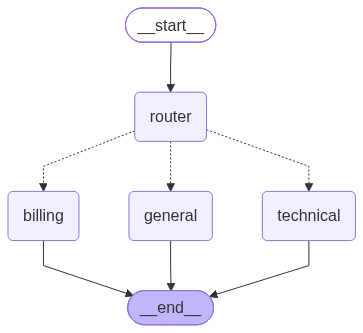

In [119]:
from IPython.display import Image, display

display(
    Image(
        routing_graph.get_graph().draw_mermaid_png()
    )
)

### 3.4 Test the Routing Workflow

**Model-call note:** This test normally makes **2 model calls**: one for classification and one for the selected specialist.

#### Expected behavior

1. The router classifies the duplicate-charge query.
2. Only one specialist branch runs.
3. The selected route should normally be `billing`.
4. The complete graph state is saved in `routing_result`.

Run the runner-definition cell first and then run the invocation cell below it.


In [120]:
def run_routing():
    print("\n" + "=" * 70)
    print("3. ROUTING")
    print("=" * 70)

    graph = build_routing_graph()

    result = graph.invoke(
        {
            "query": "My credit card was charged twice."
        }
    )

    print(
        "Selected route:",
        result["route"],
    )

    print(
        "\nResponse:\n",
        result["response"],
    )

    return result


In [121]:
routing_result = run_routing()



3. ROUTING
Selected route: billing

Response:
 I'm sorry to hear that your credit card was charged twice. To assist you better, could you please provide the following details?

1. The date(s) of the charges.
2. The amount charged.
3. The name of the merchant or service.
4. Any transaction or order numbers you have.

Once I have this information, I can help investigate the issue and guide you on the next steps to resolve the double charge.


#### Common mistakes

- Returning a route name that is missing from the conditional-edge mapping.
- Using free-form routing text instead of a structured output schema.
- Accidentally connecting every specialist so that all branches run.

#### Student exercise

Add a `refund` route, a refund specialist node, and one test query that should select it.


## 4. Orchestrator–Worker — schemas and state

### What this workflow does

An orchestrator breaks a large task into smaller tasks. Dynamic workers complete those tasks, and a synthesizer combines all worker results into one final report.

### How it works

1. `orchestrator` asks the planner to create report sections.
2. `assign_workers` uses `Send` to create one worker execution for every section.
3. Each `worker` writes only its assigned section.
4. `operator.add` collects all completed sections in one list.
5. `synthesizer` joins the sections and creates `final_report`.

```text
Large Task → Create Plan → Send Sections to Workers → Collect Work → Final Report
```

### Simple real-world example

Imagine a teacher assigning a project report. The teacher creates sections such as introduction, benefits, challenges, and conclusion. Different students write different sections, and one editor combines them into a single report. In the notebook, workers create sections for a report about `AI Agents in Enterprise`.


In [131]:
# ============================================================
# 4. ORCHESTRATOR-WORKER WITH Send()
# ============================================================
class Section(BaseModel):
    name: str 
    description: str

In [132]:
class Sections(BaseModel):
    sections: list[Section]

In [133]:
planner = model.with_structured_output(
    Sections
)

In [134]:
class OrchestratorState(TypedDict):
    topic: str
    sections: list[Section]

    completed_sections: Annotated[
        list[str],
        operator.add,
    ]

    final_report: str

In [135]:
class WorkerState(TypedDict):
    section: Section

    completed_sections: Annotated[
        list[str],
        operator.add,
    ]


### 4.1 Orchestrator, `Send` dispatcher, workers, and synthesizer

`Send` creates one worker task per planned section; the synthesizer joins all completed sections.


In [136]:
def orchestrator(state: OrchestratorState):
    result = planner.invoke(
        f"""
Create a report plan for:

{state['topic']}

Create appropriate sections.
"""
    )

    return {
        "sections": result.sections
    }

In [50]:
def worker(state: WorkerState):
    section = state["section"]

    response = model.invoke(
        f"""
Write this report section.

Section:
{section.name}

Description:
{section.description}
"""
    )

    return {
        "completed_sections": [
            f"## {section.name}\n\n{response.content}"
        ]
    }

In [137]:
def assign_workers(state: OrchestratorState):
    return [
        Send(
            "worker",
            {
                "section": section
            },
        )
        for section in state["sections"]
    ]

In [138]:
def synthesizer(state: OrchestratorState):
    report = "\n\n".join(
        state["completed_sections"]
    )

    return {
        "final_report": report
    }

### 4.2 Build the orchestrator–worker graph

The explicit `['worker']` path map also keeps the dynamic destination visible in graph diagrams.


In [139]:
def build_orchestrator_worker_graph():
    builder = StateGraph(
        OrchestratorState
    )

    builder.add_node(
        "orchestrator",
        orchestrator,
    )

    builder.add_node(
        "worker",
        worker,
    )

    builder.add_node(
        "synthesizer",
        synthesizer,
    )

    builder.add_edge(
        START,
        "orchestrator",
    )

    builder.add_conditional_edges(
        "orchestrator",
        assign_workers,
        ["worker"],
    )

    builder.add_edge(
        "worker",
        "synthesizer",
    )

    builder.add_edge(
        "synthesizer",
        END,
    )

    return builder.compile()


### 4.3 Generated graph structure

This diagram is generated from the compiled graph, so it stays aligned with the actual nodes and edges. Running it does not make a model call.


In [140]:
orchestrator_worker_graph = build_orchestrator_worker_graph()
show_graph(orchestrator_worker_graph)


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	orchestrator(orchestrator)
	worker(worker)
	synthesizer(synthesizer)
	__end__([<p>__end__</p>]):::last
	__start__ --> orchestrator;
	orchestrator -.-> worker;
	worker --> synthesizer;
	synthesizer --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



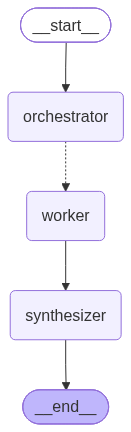

In [141]:
from IPython.display import Image, display

display(
    Image(
        orchestrator_worker_graph.get_graph().draw_mermaid_png()
    )
)

### 4.4 Test the Orchestrator–Worker Workflow

**Model-call note:** This test makes **1 planner call plus 1 call for every generated section**. The number of calls is dynamic.

#### Expected behavior

1. The planner returns a structured list of report sections.
2. `Send` creates one worker execution for every section.
3. The reducer collects all worker results.
4. The final report contains a heading for each section and is saved in `orchestrator_result`.

Run the runner-definition cell first and then run the invocation cell below it.


In [142]:
def run_orchestrator_worker():
    print("\n" + "=" * 70)
    print("4. ORCHESTRATOR-WORKER WITH Send()")
    print("=" * 70)

    graph = build_orchestrator_worker_graph()

    result = graph.invoke(
        {
            "topic": "AI Agents in Enterprise",
            "completed_sections": [],
        }
    )

    print(
        result["final_report"]
    )

    return result

In [143]:
orchestrator_result = run_orchestrator_worker()


4. ORCHESTRATOR-WORKER WITH Send()
## Introduction

## Introduction

Artificial Intelligence (AI) agents are autonomous software entities designed to perform tasks, make decisions, and interact with their environment with minimal human intervention. Leveraging advanced algorithms, machine learning, and data analytics, these agents can perceive inputs, process information, and execute actions to achieve specific goals. In the enterprise context, AI agents have become increasingly significant as organizations seek to enhance operational efficiency, improve customer experiences, and drive innovation.

The integration of AI agents within business processes enables automation of routine tasks, real-time data analysis, and adaptive decision-making, which collectively contribute to reducing costs and accelerating workflows. Moreover, AI agents facilitate personalized interactions in customer service, optimize supply chain management, and support strategic planning through predictive insights

In [144]:
orchestrator_result

{'topic': 'AI Agents in Enterprise',
 'sections': [Section(name='Introduction', description='Overview of AI agents and their significance in the enterprise context.'),
  Section(name='Types of AI Agents', description='Detailed explanation of various AI agents used in enterprises, including reactive agents, deliberative agents, and hybrid agents.'),
  Section(name='Applications in Enterprise', description='Exploration of how AI agents are applied across different enterprise functions such as customer service, supply chain management, and decision support.'),
  Section(name='Benefits of AI Agents', description='Analysis of the advantages AI agents bring to enterprises, including efficiency, scalability, and improved decision-making.'),
  Section(name='Challenges and Risks', description='Discussion of potential challenges and risks associated with deploying AI agents in enterprises, such as ethical concerns, security, and integration issues.'),
  Section(name='Case Studies', description='

#### Common mistakes

- Removing the `operator.add` reducer from `completed_sections`.
- Passing the full parent state when each worker only needs one `section`.
- Depending on a particular worker-completion order.

#### Student exercise

Ask the planner for exactly three sections and verify that the final report contains all three section headings.


## 5. Evaluator–Optimizer — schemas and state

### What this workflow does

An evaluator–optimizer workflow creates an answer, checks its quality, and improves it when necessary. The loop stops when the evaluator accepts the answer or after three attempts.

### How it works

1. `generator` writes an answer for the given topic.
2. `evaluator` checks correctness, clarity, simplicity, and conciseness.
3. The evaluator returns `accepted` or `needs_improvement` with feedback.
4. An accepted answer moves to `END`.
5. An answer needing improvement returns to `generator`, together with the feedback.
6. After three unsuccessful attempts, `stop_evaluation` ends the workflow safely.

```text
Generate Answer → Evaluate Quality → Accept
       ↑                 │
       └── Improve Using Feedback
```

### Simple real-world example

Imagine a student writing an essay. A teacher reviews it and either accepts it or gives feedback such as `add an example` or `make the explanation simpler`. The student rewrites the essay using that feedback, but the teacher stops after three drafts if the work is still not ready. The notebook applies this bounded loop to an explanation of Agentic RAG.


### 1.4 Test the Sequential Workflow

**Model-call note:** This test makes **3 model calls**.

#### Expected behavior

1. A first draft is generated for Retrieval-Augmented Generation.
2. The draft is rewritten for a beginner and then polished.
3. The final polished explanation is printed.
4. The complete graph state is saved in `sequential_result`.

Run the runner-definition cell first and then run the invocation cell below it.


In [122]:
# ============================================================
# 5. EVALUATOR-OPTIMIZER
# ============================================================
class Evaluation(BaseModel):
    status: Literal[
        "accepted",
        "needs_improvement",
    ]

    feedback: str

In [123]:
evaluator_model = model.with_structured_output(
    Evaluation
)

In [124]:
class EvalState(TypedDict):
    topic: str
    answer: str
    feedback: str
    status: str
    attempts: int


### 5.1 Generator, evaluator, and routing decision

Feedback from the evaluator is included when the generator is asked to improve its answer.


In [62]:
def generator(state: EvalState):
    attempts = state.get("attempts", 0) + 1

    feedback = state.get(
        "feedback",
        "",
    )

    response = model.invoke(
        f"""
Write a high-quality explanation about:

{state['topic']}

Evaluator feedback:

{feedback}
"""
    )

    return {
        "answer": response.content,
        "attempts": attempts,
    }

In [63]:
def evaluator(state: EvalState):
    result = evaluator_model.invoke(
        f"""
Evaluate the following answer.

Criteria:
- technically correct
- beginner friendly
- clear
- concise

Answer:

{state['answer']}
"""
    )

    return {
        "status": result.status,
        "feedback": result.feedback,
    }

In [64]:
def evaluation_route(
    state: EvalState,
) -> Literal[
    "accepted",
    "needs_improvement",
    "max_attempts",
]:
    if state["status"] == "accepted":
        return "accepted"

    if state["attempts"] >= 3:
        return "max_attempts"

    return "needs_improvement"

In [65]:
def stop_evaluation(state: EvalState):
    return {
        "status": "max_attempts_reached",
        "feedback": (
            f"Stopped after {state['attempts']} attempts. "
            f"Last evaluator feedback: {state['feedback']}"
        ),
    }

### 5.2 Build the evaluator loop

Accepted answers finish at `END`; answers needing improvement loop back to the generator.


In [125]:
def build_evaluator_optimizer_graph():
    builder = StateGraph(
        EvalState
    )

    builder.add_node(
        "generator",
        generator,
    )

    builder.add_node(
        "evaluator",
        evaluator,
    )

    builder.add_node(
        "stop_evaluation",
        stop_evaluation,
    )

    builder.add_edge(
        START,
        "generator",
    )

    builder.add_edge(
        "generator",
        "evaluator",
    )

    builder.add_conditional_edges(
        "evaluator",
        evaluation_route,
        {
            "accepted": END,
            "needs_improvement": "generator",
            "max_attempts": "stop_evaluation",
        },
    )

    builder.add_edge(
        "stop_evaluation",
        END,
    )

    return builder.compile()


### 5.3 Generated graph structure

This diagram is generated from the compiled graph, so it stays aligned with the actual nodes and edges. Running it does not make a model call.


In [126]:
evaluator_optimizer_graph = build_evaluator_optimizer_graph()
show_graph(evaluator_optimizer_graph)


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	generator(generator)
	evaluator(evaluator)
	stop_evaluation(stop_evaluation)
	__end__([<p>__end__</p>]):::last
	__start__ --> generator;
	evaluator -. &nbsp;accepted&nbsp; .-> __end__;
	evaluator -. &nbsp;needs_improvement&nbsp; .-> generator;
	evaluator -. &nbsp;max_attempts&nbsp; .-> stop_evaluation;
	generator --> evaluator;
	stop_evaluation --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



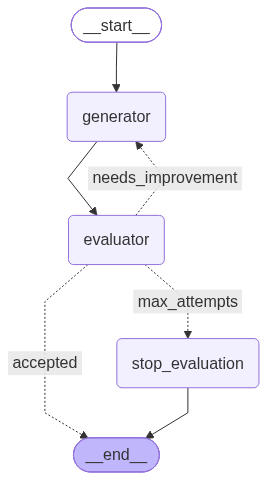

In [127]:
from IPython.display import Image, display

display(
    Image(
        evaluator_optimizer_graph.get_graph().draw_mermaid_png()
    )
)

### 5.4 Test the Evaluator–Optimizer Workflow

**Model-call note:** This test makes **2 calls per attempt** and stops after at most **3 attempts**, so it makes no more than 6 model calls.

#### Expected behavior

1. The generator creates an Agentic RAG explanation.
2. The evaluator either accepts it or returns improvement feedback.
3. The graph stops when accepted or when three attempts have been used.
4. The final answer, status, feedback, attempt count, and complete state are available in `evaluator_result`.

Run the runner-definition cell first and then run the invocation cell below it.


In [128]:
def run_evaluator_optimizer():
    print("\n" + "=" * 70)
    print("5. EVALUATOR-OPTIMIZER")
    print("=" * 70)

    graph = build_evaluator_optimizer_graph()

    result = graph.invoke(
        {
            "topic": "What is Agentic RAG?",
            "answer": "",
            "feedback": "",
            "status": "",
            "attempts": 0,
        }
    )

    print(
        result["answer"]
    )

    print(
        "\nFinal evaluation status:",
        result["status"],
    )

    print(
        "\nEvaluator feedback:",
        result["feedback"],
    )

    print(
        "\nAttempts used:",
        result["attempts"],
    )

    return result


In [129]:
evaluator_result = run_evaluator_optimizer()


5. EVALUATOR-OPTIMIZER
**Agentic RAG** refers to an advanced approach in the field of artificial intelligence that combines the principles of Retrieval-Augmented Generation (RAG) with agentic capabilities, enabling AI systems to not only retrieve and generate information but also to act autonomously and make decisions based on that information.

### Breaking Down the Components:

1. **Retrieval-Augmented Generation (RAG):**  
   RAG is a technique that enhances language models by integrating an external knowledge retrieval system. Instead of relying solely on pre-trained knowledge, a RAG model dynamically fetches relevant documents or data from a large corpus during the generation process. This allows the model to produce more accurate, up-to-date, and contextually relevant responses.

2. **Agentic Capabilities:**  
   An agentic system possesses the ability to perceive its environment, make decisions, and take actions autonomously to achieve specific goals. In AI, agentic behavior im

In [130]:
evaluator_result

{'topic': 'What is Agentic RAG?',
 'answer': '**Agentic RAG** refers to an advanced approach in the field of artificial intelligence that combines the principles of Retrieval-Augmented Generation (RAG) with agentic capabilities, enabling AI systems to not only retrieve and generate information but also to act autonomously and make decisions based on that information.\n\n### Breaking Down the Components:\n\n1. **Retrieval-Augmented Generation (RAG):**  \n   RAG is a technique that enhances language models by integrating an external knowledge retrieval system. Instead of relying solely on pre-trained knowledge, a RAG model dynamically fetches relevant documents or data from a large corpus during the generation process. This allows the model to produce more accurate, up-to-date, and contextually relevant responses.\n\n2. **Agentic Capabilities:**  \n   An agentic system possesses the ability to perceive its environment, make decisions, and take actions autonomously to achieve specific goa

#### Common mistakes

- Creating a feedback loop without a maximum-attempt condition.
- Ignoring evaluator feedback when generating the next answer.
- Returning a status that is missing from the conditional-edge mapping.

#### Student exercise

Change the attempt limit from three to two and observe the `max_attempts_reached` terminal status.


## 6. Agent Loop — tools and model binding

### What this workflow does

A tool-calling agent decides whether it can answer directly or needs to use a tool. Tool results are returned to the agent so it can continue reasoning and produce the final response.

### How it works

1. `agent_node` sends the conversation messages to the tool-enabled model.
2. `should_continue` checks whether the model requested a tool call.
3. If a tool is requested, `ToolNode` executes `multiply` or `add`.
4. The tool result is added to `MessagesState` and sent back to the agent.
5. When no more tool calls are required, the graph moves to `END`.

```text
User Question → Agent → Tool Call → Tool Result → Agent → Final Answer
```

### Simple real-world example

A user asks, `Multiply 12 and 8, then add 10.` The agent can call `multiply(12, 8)` to get 96, then call `add(96, 10)` to get 106. After receiving the tool results, it returns the final answer to the user.


In [145]:
# ============================================================
# 6. AGENT LOOP WITH TOOLS
# ============================================================

@tool
def multiply(
    a: int,
    b: int,
) -> int:
    """Multiply two numbers."""

    return a * b


@tool
def add(
    a: int,
    b: int,
) -> int:
    """Add two numbers."""

    return a + b


tools = [
    multiply,
    add,
]


model_with_tools = model.bind_tools(
    tools
)


tool_node = ToolNode(
    tools
)

### 6.1 Agent node and continuation condition

The graph continues to the tool node while the latest AI message contains tool calls.


In [146]:
def ai_assistant(state: MessagesState):
    response = model_with_tools.invoke(
        state["messages"]
    )

    return {
        "messages": [
            response
        ]
    }


def should_continue(state: MessagesState):
    last_message = state["messages"][-1]

    if last_message.tool_calls:
        return "tools"

    return "end"

### 6.2 Build the tool-calling loop

The graph loops `agent → tools → agent` until the model returns a final response.


In [147]:
def build_agent_graph():
    builder = StateGraph(
        MessagesState
    )

    builder.add_node(
        "ai_assistant",
        ai_assistant,
    )

    builder.add_node(
        "tools",
        tool_node,
    )

    builder.add_edge(
        START,
        "ai_assistant",
    )

    builder.add_conditional_edges(
        "ai_assistant",
        should_continue,
        {
            "tools": "tools",
            "end": END,
        },
    )

    builder.add_edge(
        "tools",
        "ai_assistant",
    )

    return builder.compile()

### 6.3 Generated graph structure

This diagram is generated from the compiled graph, so it stays aligned with the actual nodes and edges. Running it does not make a model call.


In [148]:
agent_graph = build_agent_graph()
show_graph(agent_graph)


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	ai_assistant(ai_assistant)
	tools(tools)
	__end__([<p>__end__</p>]):::last
	__start__ --> ai_assistant;
	ai_assistant -. &nbsp;end&nbsp; .-> __end__;
	ai_assistant -.-> tools;
	tools --> ai_assistant;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



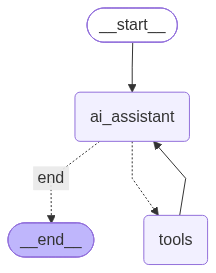

In [149]:
from IPython.display import Image, display

display(
    Image(
        agent_graph.get_graph().draw_mermaid_png()
    )
)

### 6.4 Test the Tool-Calling Agent Loop

**Model-call note:** The number of model calls is **dynamic**. This two-step calculation usually needs multiple model turns and two tool executions.

#### Expected behavior

1. The model requests the multiplication and addition tools when needed.
2. `ToolNode` executes each requested calculation.
3. Tool results return to the agent through `MessagesState`.
4. The final answer should be 106, and the complete message state is saved in `agent_result`.

Run the runner-definition cell first and then run the invocation cell below it.


In [150]:
def run_agent_loop():
    print("\n" + "=" * 70)
    print("6. AGENT LOOP WITH TOOLS")
    print("=" * 70)

    graph = build_agent_graph()

    result = graph.invoke(
        {
            "messages": [
                HumanMessage(
                    content=(
                        "Multiply 12 and 8, "
                        "then add 10."
                    )
                )
            ]
        }
    )

    print(
        result["messages"][-1].content
    )

    return result


In [151]:
agent_result = run_agent_loop()



6. AGENT LOOP WITH TOOLS
The result of multiplying 12 and 8, then adding 10 is 106.


In [152]:
agent_result

{'messages': [HumanMessage(content='Multiply 12 and 8, then add 10.', additional_kwargs={}, response_metadata={}, id='28698e11-1588-4041-a0b0-4cbe9213e831'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 77, 'total_tokens': 127, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_6adc023d19', 'id': 'chatcmpl-EQFBfwplmePTtM5oG6yt7RI3osgL4', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0bfc2-db75-7981-a049-f9b0e7a797b1-0', tool_calls=[{'name': 'multiply', 'args': {'a': 12, 'b': 8}, 'id': 'call_MVwjbpDdmHffNDBjUNqEc3xl', 'type': 'tool_call'}, {'name': 'add', 'args': {'a': 0, 'b': 

#### Common mistakes

- Creating tools but forgetting to bind them to the model.
- Forgetting the edge from `tools` back to `agent`.
- Using unclear tool names, types, or docstrings.

#### Student exercise

Add a `subtract` tool and test a request that requires multiplication, addition, and subtraction.
